In [1]:
# 1. Import liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2.Load Dataset
df=pd.read_csv("netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [29]:
# 3. Basic Dataset Exploration
df.shape
df.info()
df.isnull().sum()

# Insight:
# a. Dataset contains Netflix Movies and TV Shows information.
# b. Columns include title, cast, director, country, genre, release year etc.

<class 'pandas.core.frame.DataFrame'>
Index: 8709 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8709 non-null   object        
 1   type          8709 non-null   object        
 2   title         8709 non-null   object        
 3   director      6168 non-null   object        
 4   cast          7892 non-null   object        
 5   country       7882 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8709 non-null   int64         
 8   rating        8705 non-null   object        
 9   duration      8706 non-null   object        
 10  listed_in     8709 non-null   object        
 11  description   8709 non-null   object        
 12  month         8709 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(10)
memory usage: 1.1+ MB


show_id            0
type               0
title              0
director        2541
cast             817
country          827
date_added         0
release_year       0
rating             4
duration           3
listed_in          0
description        0
month              0
dtype: int64

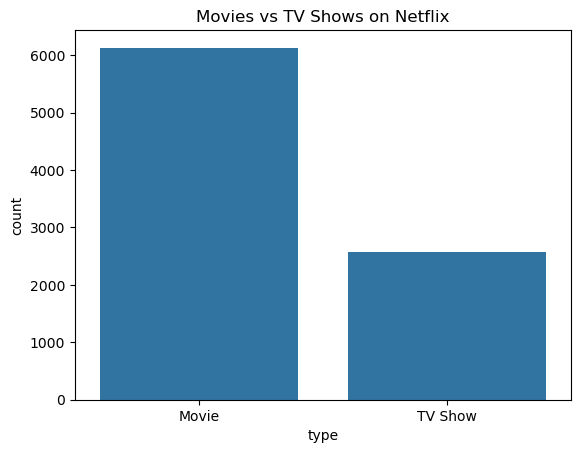

In [30]:
# 4. Movies VS TV Shows Ratio
df['type'].value_counts()
sns.countplot(x='type',data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.show()

# Insight:
# a. Netflix has more Movies than TV Shows.
# b. Movies are easier and cheaper to produce than series.

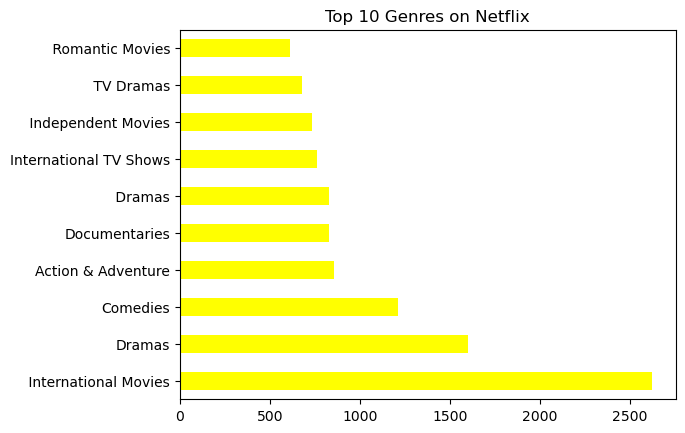

In [31]:
# 5. Most Popular Genres
genres=df['listed_in'].str.split(',',expand=True).stack()
genres.value_counts().head(10).plot(kind='barh',color="yellow")
plt.title("Top 10 Genres on Netflix")
plt.show()

# Insights:
# a. Drama, International Movies and Comedy dominate Netflix.
# b. These genres attract global audiences.

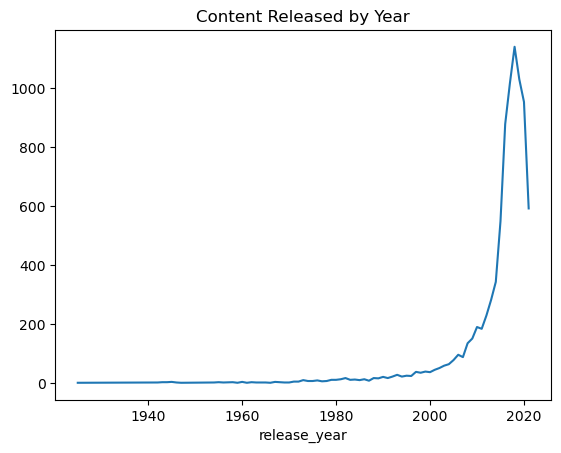

In [32]:
# 6. Content Released by Year
df['release_year'].value_counts().sort_index().tail(20)
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Released by Year")
plt.show()

# Insight:
# Content production increased rapidly after 2015.

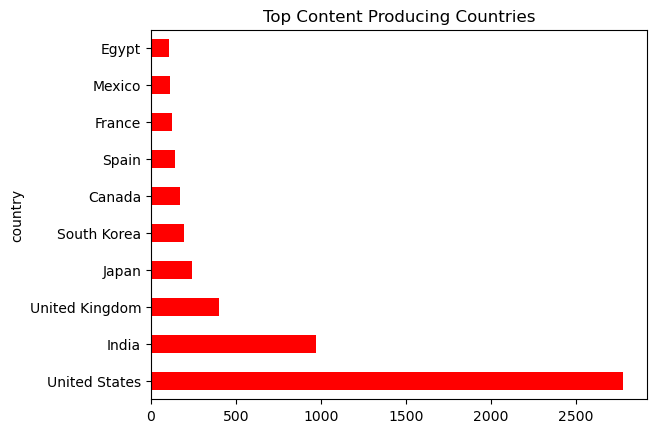

In [33]:
# 7.Countries Producing Most Content
df['country'].value_counts().head(10).plot(kind='barh',color="red")
plt.title("Top Content Producing Countries")
plt.show()

# Insight:
# a. USA produces the highest content.
# b. Followed by India and UK.

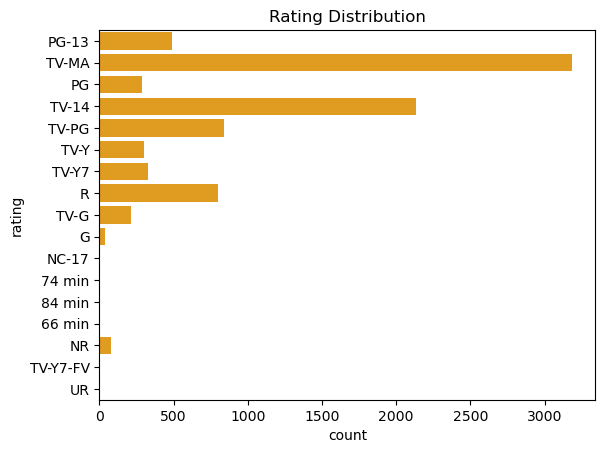

In [34]:
# 8.Rating Distribution
df['rating'].value_counts()
sns.countplot(y='rating',data=df,color="orange")
plt.title("Rating Distribution")
plt.show()

# Insight:
# TV-MA rating is most common meaning content targets adults.

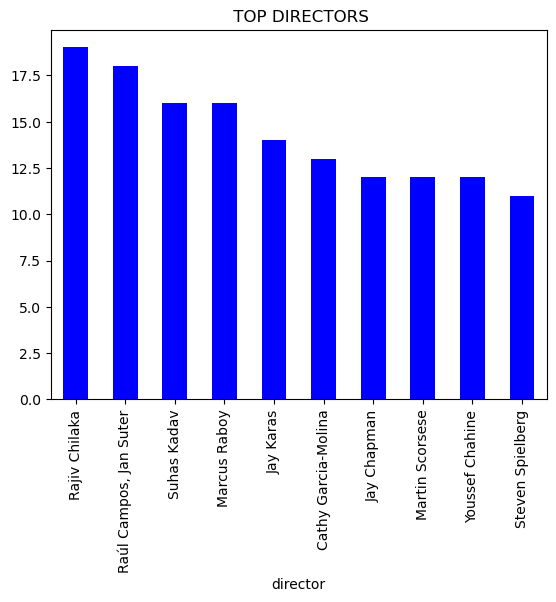

In [35]:
# 9.Top Directors
df['director'].value_counts().head(10).plot(kind='bar',color='blue')
plt.title(" TOP DIRECTORS")
plt.show()

# Insight:
# Certain directors appear frequently, meaning Netflix collaboration repeatedly with successful creators.

In [36]:
# 10. Most frequent Actors
actors=df['cast'].str.split(',',expand=True).stack()
actors.value_counts().head(10)
print(actors)

# Insight:
# a. These actors appear most frequently in Netflix content.

1     0                Ama Qamata
      1               Khosi Ngema
      2             Gail Mabalane
      3            Thabang Molaba
      4          Dillon Windvogel
                    ...          
8806  3          Manish Chaudhary
      4              Meghna Malik
      5             Malkeet Rauni
      6            Anita Shabdish
      7     Chittaranjan Tripathy
Length: 63444, dtype: object


In [18]:
# 12. Average Movie Duration
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min','')

movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

movies['duration'].mean()

# Insight:
# Average movie duration is around 90-100 minutes.

np.float64(99.57718668407311)

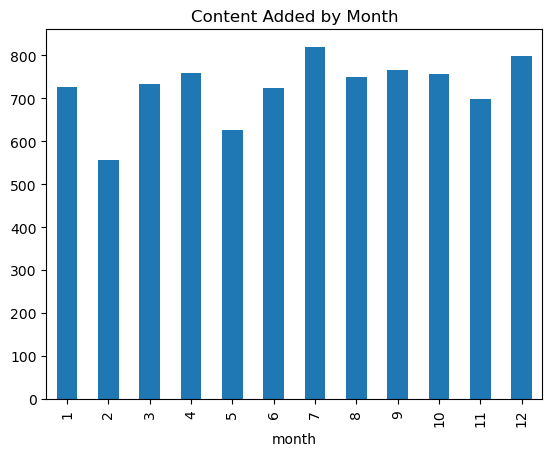

In [21]:
# 13. Best Month to Release Content
#string into NaT
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')
df=df.dropna(subset=['date_added'])
df['month']=df['date_added'].dt.month
df['month'].value_counts().sort_index().plot(kind='bar')
plt.title("Content Added by Month")
plt.show()

# Insight:
# a. Netflix adds most content during mid-year and year-end.

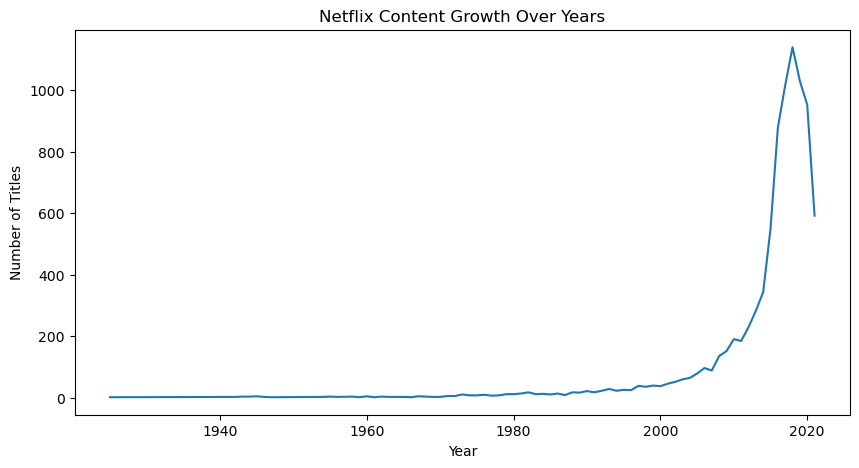

In [22]:
# 15.Netflix Content Growth Over Time
df['release_year'].value_counts().sort_index().plot(figsize=(10,5))
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

# Insights:
# a. Netflix content increased rapidly after 2015.
# b. This shows Netflix started investing heavily in original content during recent years.

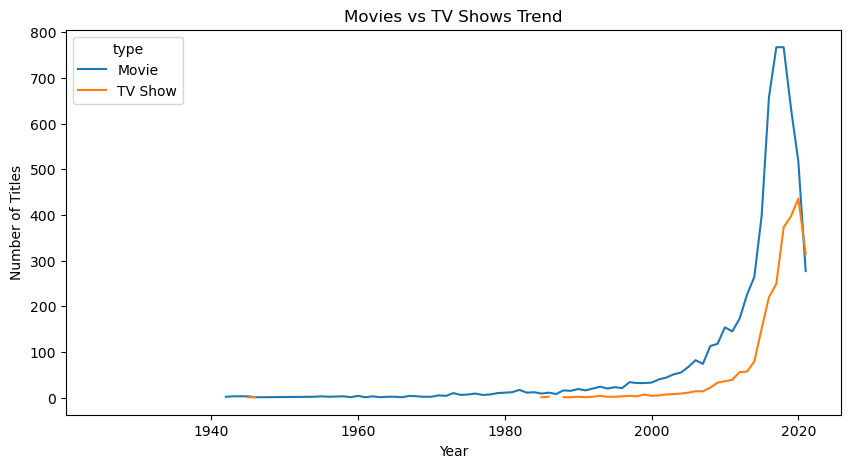

In [23]:
#16. Movies vs TV Shows Trend Over Years
content_trend=df.groupby(['release_year','type']).size().unstack()
content_trend.plot(figsize=(10,5))
plt.title("Movies vs TV Shows Trend")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

# Insights:
# a. Movies dominate Netflix overall.
# b. But TV Shows have increased in recent years, indicating Netflix is focusing on long-form content.

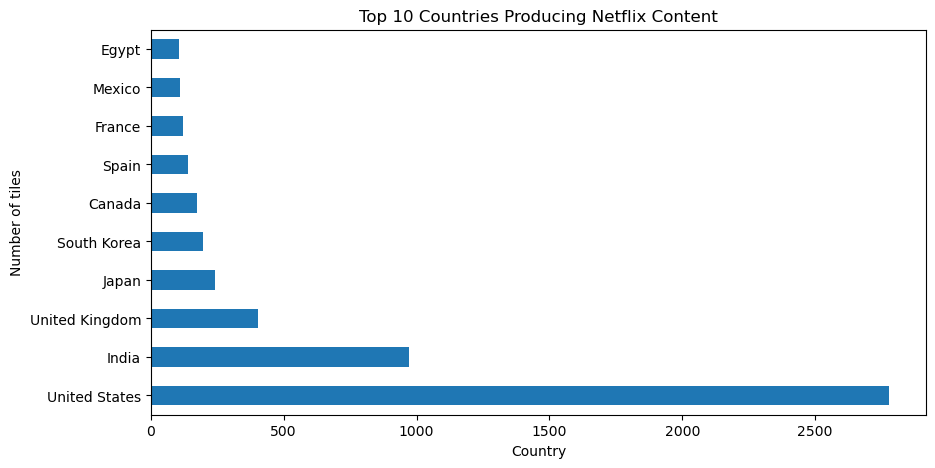

In [24]:
#17.Top 10 Countries Producing Netflix Content
df['country'].value_counts().head(10).plot(kind='barh',figsize=(10,5))
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of tiles")
plt.show()

# Insights:
# a. USA produces the highest number of netflix titles.
# b. India and the UK are also strong content contributors.

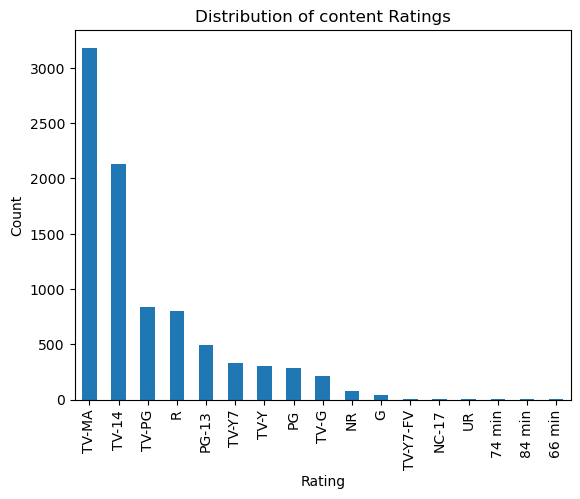

In [25]:
#18.Most Common Ratings
df['rating'].value_counts().plot(kind='bar')
plt.title("Distribution of content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

#Insights:
# TV-MA rating dominates Netflix, meaning most content targets mature audiences.

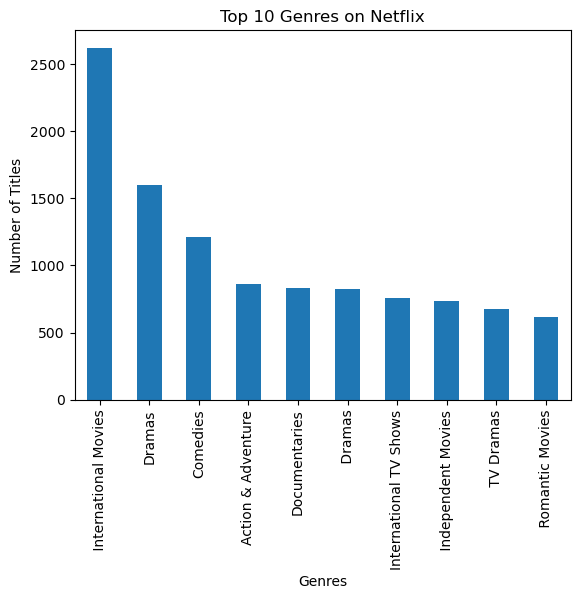

In [27]:
#19.Top 10 Genres
genres=df['listed_in'].str.split(',', expand=True).stack()
genres.value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genres")
plt.ylabel("Number of Titles")
plt.show()

# Insights:
#   Drama, Comedy, and International Movies are the most common genres.
#   These genres attract the widest audience globally.


In [28]:
# 20. Final Business Recommendation:
# 1.Netflix should continue investing in Drama and Comedy genres.
# 2.Increase production in high-performing markets like USA and India.
# 3.Expand TV Shows content since series increase user retention.
# 4.Collaborate with frequently appearing directors and actors.
# 5.Focus on mature audience content(TV-MA) as it dominates the platform.